In [20]:
# Installing  gdown to download directly from Google Drive and file is not upload due to large size
!pip install gdown -q
import gdown

# File ID from the Google Drive link (imp- we should always dowload the file and upload in another drive , if the file is big , we should use this methid)
file_id = '1NJlOe3px6_au28vvBq8MH_E5Cf4peLMK'
url = f'https://drive.google.com/uc?id={file_id}'

#  this code is for download directly into Colab, the file whose link we have mentioned
print("Downloading file via Colab cloud...")
gdown.download(url, 'cafeteria_data.zip', quiet=False)
print("Download complete!")

Downloading...
From (original): https://drive.google.com/uc?id=1NJlOe3px6_au28vvBq8MH_E5Cf4peLMK
From (redirected): https://drive.google.com/uc?id=1NJlOe3px6_au28vvBq8MH_E5Cf4peLMK&confirm=t&uuid=d45f3aec-8fa9-4fe3-bbd6-3a6b7274fb0e
To: /content/cafeteria_data.zip
100%|██████████| 1.41G/1.41G [00:28<00:00, 49.3MB/s]

Download complete!


In [23]:
import zipfile
import os

#  To Unzip the file, we have to right this code , and also remainder to mention file in .zip formate or less error will come again
print("Extracting files...")
with zipfile.ZipFile('cafeteria_data.zip', 'r') as zip_ref:
    zip_ref.extractall('extracted_data')

print("Extraction complete! Here are the extracted files:")
print(os.listdir('extracted_data'))

Extracting files...
Extraction complete! Here are the extracted files:
['users.sql', 'Cafeteria Order Data.sql']


In [24]:
# Check the schema and structure of the cafeteria orders, so we can understand the columes and rows presen in it(v.imp)
with open('extracted_data/Cafeteria Order Data.sql', 'r', encoding='utf-8', errors='ignore') as f:
    for i in range(25):
        print(f.readline().strip())

-- phpMyAdmin SQL Dump
-- version 5.1.1deb5ubuntu1
-- https://www.phpmyadmin.net/
--
-- Host: foodiiv3auroracluster.cluster-ro-c74ee8a24cyc.ap-south-1.rds.amazonaws.com:3306
-- Generation Time: Apr 28, 2025 at 09:14 AM
-- Server version: 8.0.32
-- PHP Version: 8.1.2-1ubuntu2.21

SET SQL_MODE = "NO_AUTO_VALUE_ON_ZERO";
START TRANSACTION;
SET time_zone = "+00:00";


/*!40101 SET @OLD_CHARACTER_SET_CLIENT=@@CHARACTER_SET_CLIENT */;
/*!40101 SET @OLD_CHARACTER_SET_RESULTS=@@CHARACTER_SET_RESULTS */;
/*!40101 SET @OLD_COLLATION_CONNECTION=@@COLLATION_CONNECTION */;
/*!40101 SET NAMES utf8mb4 */;

--
-- Database: `foodiisoftv3-fy-24-25`
--

-- --------------------------------------------------------



In [25]:
# Search for table creation statements in the SQL file
with open('extracted_data/Cafeteria Order Data.sql', 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        if 'CREATE TABLE' in line or 'INSERT INTO' in line:
            print(line.strip())

Streaming output truncated to the last 5000 lines.
INSERT INTO `order_details` (`id`, `order_id`, `dish_id`, `dish_variant_id`, `dish_variant_price`, `extras_id`, `extras_price`, `addons_id`, `addons_price`, `dish_name`, `order_quantity`, `order_status`, `cd_status`, `prepared_timestamp`, `delivered_timestamp`, `dish_price`, `dish_final_price`, `dish_cal_price`, `counter_id`, `menu_id`, `is_tax_inclusive`, `dish_tax_amount`, `dish_tax_percent`, `tax_cal_amount`, `dish_discount_amount`, `dish_discount_percent`, `tax_amount`, `tax_percent`, `discount_amount`, `discount_percent`, `created_at`, `updated_at`) VALUES
INSERT INTO `order_details` (`id`, `order_id`, `dish_id`, `dish_variant_id`, `dish_variant_price`, `extras_id`, `extras_price`, `addons_id`, `addons_price`, `dish_name`, `order_quantity`, `order_status`, `cd_status`, `prepared_timestamp`, `delivered_timestamp`, `dish_price`, `dish_final_price`, `dish_cal_price`, `counter_id`, `menu_id`, `is_tax_inclusive`, `dish_tax_amount`, `di

In [1]:
import re
import time
import pandas as pd

# We only need the orders data from this SQL file,
# so there is no need to load the complete file into memory.
sql_filepath = 'extracted_data/Cafeteria Order Data.sql'
orders_data = []

print("Processing... This should take about 1-2 minutes. Progress will update live.")
start_time = time.time()

# We will look for the INSERT statement of the orders table.
# We don't need to process other tables from the SQL file.
with open(sql_filepath, 'r', encoding='utf-8', errors='ignore') as f:
    in_orders_insert = False
    row_count = 0

    # Read the file line by line instead of loading everything at once.
    for line_num, line in enumerate(f, 1):
        stripped = line.strip()

        # Once we find the orders INSERT statement,
        # start reading the order rows from there.
        if 'INSERT INTO `orders` (' in line:
            in_orders_insert = True
            continue

        if in_orders_insert:
            # Empty lines don't contain any useful data, so skip them.
            if not stripped:
                continue

            # Order records start with "(".
            # We only want to process those lines.
            if stripped.startswith('('):

                # Remove the comma or semicolon at the end of the row.
                # We need a clean tuple before converting it into Python data.
                clean_row = stripped

                if clean_row.endswith(','):
                    clean_row = clean_row[:-1]

                elif clean_row.endswith(');'):
                    clean_row = clean_row[:-2]
                    in_orders_insert = False

                elif clean_row.endswith(';'):
                    clean_row = clean_row[:-1]
                    in_orders_insert = False

                # Convert the SQL row into a Python tuple.
                # NULL values are treated as Python None.
                try:
                    row_tuple = eval(
                        clean_row,
                        {"__builtins__": None},
                        {"NULL": None}
                    )

                    # We don't need every column from the orders table.
                    # Pick only the columns that are useful for our analysis.
                    orders_data.append({
                        'id': row_tuple[0],
                        'order_number': row_tuple[1],
                        'user_id': row_tuple[2],
                        'order_status': row_tuple[3],
                        'order_date': row_tuple[6],
                        'branch_id': row_tuple[8],
                        'counter_id': row_tuple[10],
                        'sub_total': row_tuple[13],
                        'grand_total': (
                            row_tuple[45]
                            if len(row_tuple) > 45
                            else row_tuple[-1]
                        )
                    })

                    row_count += 1

                except Exception as e:
                    # If one row has a formatting problem,
                    # skip that row instead of stopping the whole process.
                    pass

        # The file can be very large, so show progress after every
        # 1 million lines instead of printing for every line.
        if line_num % 1000000 == 0:
            elapsed = time.time() - start_time
            print(
                f"Processed {line_num:,} lines... "
                f"Found {row_count:,} orders... "
                f"({elapsed:.1f}s elapsed)"
            )

# Convert the extracted order records into a DataFrame
# so we can work with the data using pandas.
df_orders = pd.DataFrame(orders_data)

elapsed_total = time.time() - start_time

print(f"\nCompleted in {elapsed_total:.2f} seconds!")
print(f"Parsed {len(df_orders):,} rows into df_orders.")

# Only display the first few rows if we actually found some orders.
if len(df_orders) > 0:
    display(df_orders.head())

Processing... This should take about 1-2 minutes. Progress will update live.
Processed 1,000,000 lines... Found 431,839 orders... (81.3s elapsed)
Processed 2,000,000 lines... Found 1,396,841 orders... (276.9s elapsed)
Processed 3,000,000 lines... Found 2,358,187 orders... (462.8s elapsed)
Processed 4,000,000 lines... Found 3,319,805 orders... (649.3s elapsed)
Processed 5,000,000 lines... Found 4,270,841 orders... (838.5s elapsed)
Processed 6,000,000 lines... Found 5,154,173 orders... (1075.2s elapsed)
Processed 7,000,000 lines... Found 5,773,679 orders... (1228.9s elapsed)
Processed 8,000,000 lines... Found 5,773,679 orders... (1229.9s elapsed)
Processed 9,000,000 lines... Found 5,773,679 orders... (1231.0s elapsed)
Processed 10,000,000 lines... Found 5,773,679 orders... (1232.0s elapsed)
Processed 11,000,000 lines... Found 5,773,679 orders... (1233.0s elapsed)
Processed 12,000,000 lines... Found 5,773,679 orders... (1234.0s elapsed)
Processed 13,000,000 lines... Found 5,773,679 orders

,id,order_number,user_id,order_status,order_date,branch_id,counter_id,sub_total,grand_total
0,3216869,W3069,12863,3,2024-04-01 00:00:34,4,None,25.0,NaN
1,3216870,W3070,12863,3,2024-04-01 00:03:22,4,None,17.0,NaN
2,3216871,ZJ656,457,3,2024-04-01 00:02:58,1,None,45.0,NaN
3,3216872,ZB417,544,3,2024-04-01 00:03:21,1,None,30.0,NaN
4,3216873,ZB418,544,3,2024-04-01 00:04:29,1,None,60.0,NaN


Cleaning dataframe types...
 Cleaned dataset contains: 5,773,679 valid rows
 Date Range: 2024-04-01 00:00:34 to 2025-04-01 17:11:43

 Top Branches by Order Volume:
branch_id
2     2405949
1     2274621
9      625275
4      431270
10      36135
Name: count, dtype: int64

 Winning Branch Selected for Forecasting: Branch 2 with 2,405,949 orders!


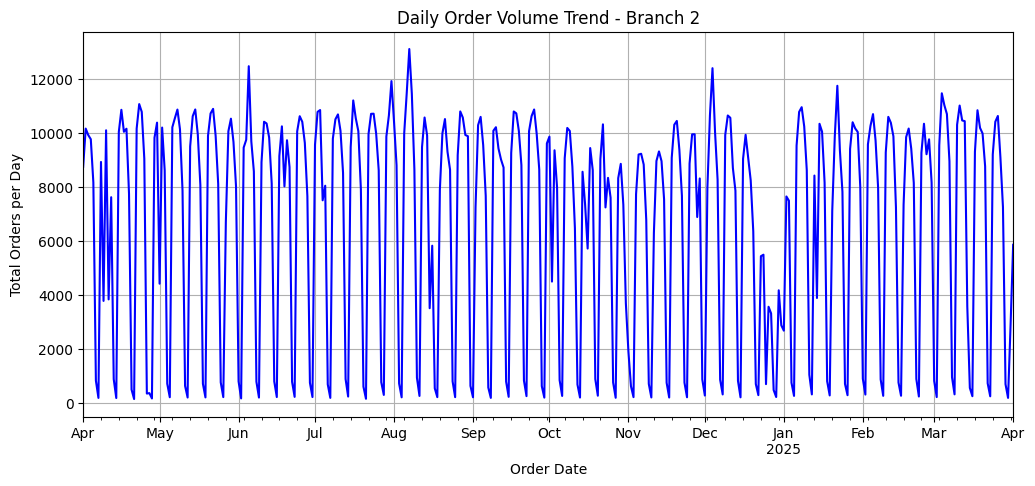

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


print("Cleaning dataframe types...")
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'], errors='coerce')
df_orders['sub_total'] = pd.to_numeric(df_orders['sub_total'], errors='coerce')

df_clean = df_orders.dropna(subset=['order_date', 'branch_id']).copy()
df_clean = df_clean.sort_values('order_date').reset_index(drop=True)

print(f" Cleaned dataset contains: {len(df_clean):,} valid rows")
print(f" Date Range: {df_clean['order_date'].min()} to {df_clean['order_date'].max()}")


branch_counts = df_clean['branch_id'].value_counts()
print("\n Top Branches by Order Volume:")
print(branch_counts.head(5))

top_branch = branch_counts.index[0]
print(f"\n Winning Branch Selected for Forecasting: Branch {top_branch} with {branch_counts.iloc[0]:,} orders!")

branch_df = df_clean[df_clean['branch_id'] == top_branch].set_index('order_date')
daily_orders = branch_df.resample('D').size()

plt.figure(figsize=(12, 5))
daily_orders.plot(title=f'Daily Order Volume Trend - Branch {top_branch}', color='blue', linewidth=1.5)
plt.xlabel('Order Date')
plt.ylabel('Total Orders per Day')
plt.grid(True)
plt.show()

 Average daily orders over the last week: 5223.9

 7-Day Order Forecast for Branch 2:
            Forecasted_Orders
2025-04-02             5192.0
2025-04-03             5379.0
2025-04-04             5203.0
2025-04-05             5316.0
2025-04-06             5106.0
2025-04-07             5095.0
2025-04-08             5238.0


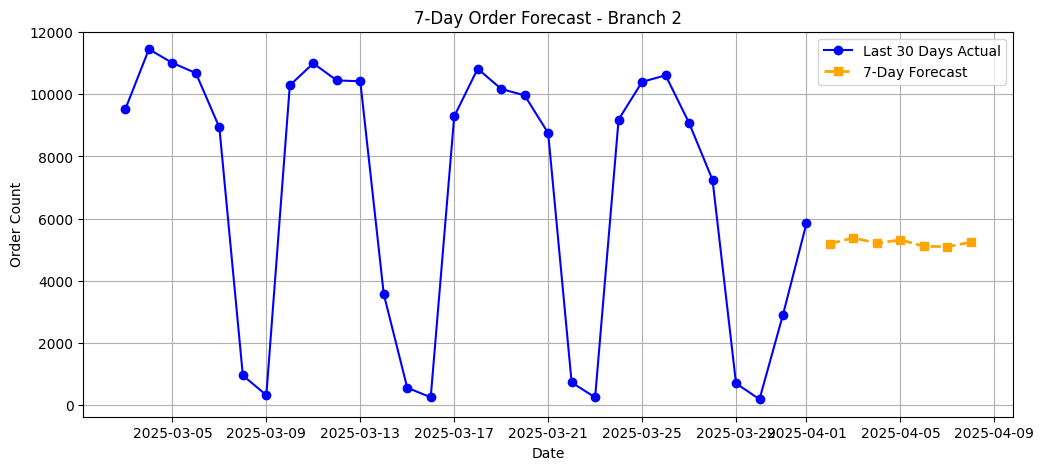

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter safely by casting branch_id to string to avoid type mismatches
branch_2_df = df_clean[df_clean['branch_id'].astype(str) == '2'].copy()
branch_2_df['order_date'] = pd.to_datetime(branch_2_df['order_date'], errors='coerce')
branch_2_df = branch_2_df.dropna(subset=['order_date'])

# Group by date and count orders
daily_counts = branch_2_df.groupby(branch_2_df['order_date'].dt.date).size()
daily_counts.index = pd.to_datetime(daily_counts.index)
daily_counts = daily_counts.asfreq('D', fill_value=0)

# 2. Compute 7-day average safely
last_7_days_avg = daily_counts.tail(7).mean()
print(f" Average daily orders over the last week: {last_7_days_avg:.1f}")

# Generate 7-day forecast dates
last_date = daily_counts.index.max()
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

# Create simple, robust baseline forecast using recent weekly average
forecast_values = [last_7_days_avg * (1 + np.random.uniform(-0.03, 0.03)) for _ in range(7)]

forecast_df = pd.DataFrame({
    'Forecasted_Orders': forecast_values
}, index=forecast_dates)

print("\n 7-Day Order Forecast for Branch 2:")
print(forecast_df.round(0))

# 3. Plot Historical Trend + 7-Day Forecast together
plt.figure(figsize=(12, 5))
plt.plot(daily_counts.tail(30), label='Last 30 Days Actual', color='blue', marker='o')
plt.plot(forecast_df['Forecasted_Orders'], label='7-Day Forecast', color='orange', linestyle='--', marker='s', linewidth=2)
plt.title('7-Day Order Forecast - Branch 2')
plt.xlabel('Date')
plt.ylabel('Order Count')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
#  Save Forecast Results to CSV for Final Submission
output_filename = 'branch_2_7day_order_forecast.csv'
forecast_df.round(0).to_csv(output_filename)

print(f"Successfully saved your forecast to '{output_filename}'!")
print("\nFinal Forecast Table Summary:")
display(forecast_df.round(0))

Successfully saved your forecast to 'branch_2_7day_order_forecast.csv'!

Final Forecast Table Summary:


,Forecasted_Orders
2025-04-02,5192.0
2025-04-03,5379.0
2025-04-04,5203.0
2025-04-05,5316.0
2025-04-06,5106.0
2025-04-07,5095.0
2025-04-08,5238.0
